<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/Chapter_5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Classification

Berbeda dengan regresi yang memprediksi nilai numerik kontinu, **klasifikasi** digunakan untuk memprediksi kategori atau label diskrit dari suatu data (misalnya: email *spam* atau *ham*, transaksi *fraud* atau *legit*, nasabah *churn* atau *tidak*). Bab ini membahas konsep inti klasifikasi mulai dari regresi logistik, matriks evaluasi, hingga algoritma berbasis pohon keputusan.

---

## 1. Naive Bayes & Logistic Regression
* **Logistic Regression:** Meskipun namanya *regression*, algoritma ini digunakan untuk klasifikasi biner. Ia memetakan nilai prediktor ke dalam probabilitas antara 0 dan 1 menggunakan fungsi *sigmoid* (logit).
* **Odds Ratio & Logit:**
  * *Odds* adalah rasio probabilitas kejadian sukses terhadap kegagalan ($p / (1-p)$).
  * *Logit* (log-odds) adalah transformasi logaritma dari odds yang membuat hubungan linear terhadap variabel prediktor.
* **Naive Bayes:** Algoritma klasifikasi probabilistik berbasis Teorema Bayes yang mengasumsikan independensi yang kuat (naif) antar fitur atau prediktornya.

---

## 2. Evaluating Classification Models (Evaluasi Model Klasifikasi)
Mengandalkan *accuracy* saja sering kali menyesatkan, terutama pada data yang tidak seimbang (*imbalanced data*). Kita memerlukan metrik evaluasi yang lebih komprehensif:
* **Confusion Matrix:** Tabel ringkasan performa model yang memuat:
  * **True Positive (TP) & True Negative (TN):** Prediksi benar untuk kelas positif dan negatif.
  * **False Positive (FP / Type I Error):** Model memprediksi positif padahal aslinya negatif.
  * **False Negative (FN / Type II Error):** Model memprediksi negatif padahal aslinya positif.
* **Accuracy:** Total tebakan yang benar dibagi seluruh data.
* **Precision:** Dari semua yang diprediksi positif, berapa persen yang benar-benar positif? ($\frac{TP}{TP + FP}$)
* **Recall (Sensitivity):** Dari semua data yang aslinya positif, berapa persen yang berhasil dideteksi oleh model? ($\frac{TP}{TP + FN}$)
* **ROC Curve & AUC (Area Under the Curve):** Kurva yang memvisualisasikan *True Positive Rate* terhadap *False Positive Rate* pada berbagai ambang batas (*threshold*), di mana AUC mengukur kemampuan keseluruhan model dalam membedakan kelas.

---

## 3. Decision Trees (Pohon Keputusan)
* **Definisi:** Algoritma non-linear yang membagi data secara berulang berdasarkan aturan keputusan fitur tertentu.
* **Gini Impurity & Entropy:** Metrik yang digunakan untuk mengukur seberapa "murni" suatu simpul (*node*) setelah pemisahan dilakukan (seberapa baik data terbagi ke dalam kelompok kelasnya masing-masing).

--- Nama-nama Kolom dalam Dataset ---
['outcome', 'payment_inc_ratio', 'dti']

--- 5 Baris Pertama Dataset Loan Classification ---


,outcome,payment_inc_ratio,dti
0,target,9.00000,22.50
1,default,5.46933,21.33
2,paid off,6.90294,8.97
3,paid off,11.14800,1.83
4,default,3.72120,10.81



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.78      0.67        27
           1       0.76      0.56      0.64        34

    accuracy                           0.66        61
   macro avg       0.67      0.67      0.66        61
weighted avg       0.68      0.66      0.65        61



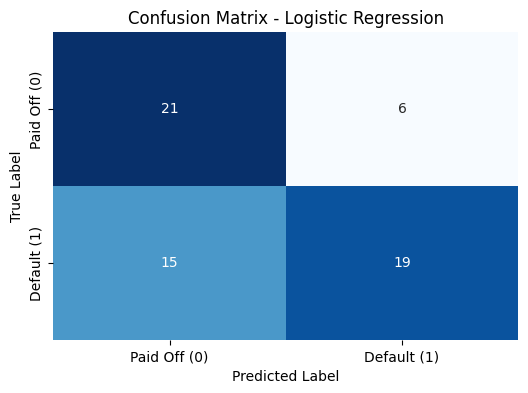

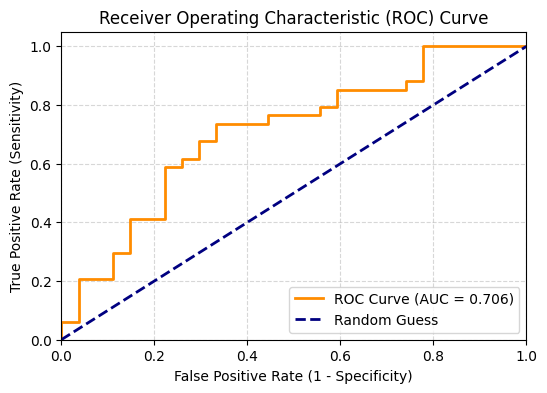

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# ==========================================
# 1. Menarik Dataset CSV Standar
# ==========================================
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loan200.csv"
loans_class = pd.read_csv(url)

print("--- Nama-nama Kolom dalam Dataset ---")
print(loans_class.columns.tolist())

print("\n--- 5 Baris Pertama Dataset Loan Classification ---")
display(loans_class.head())

# ==========================================
# 2. Persiapan Data & Pemodelan Logistic Regression
# ==========================================
# Menyesuaikan nama kolom dengan kolom yang tersedia secara aktual
# Berdasarkan buku, fitur utama untuk loan200 adalah 'payment_inc_ratio' dan 'dti'
X = loans_class[['payment_inc_ratio', 'dti']]
y = loans_class['outcome'].apply(lambda x: 1 if x == 'default' else 0)

# Membagi data menjadi training set dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Melatih model Logistic Regression
model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)

# Melakukan prediksi pada data test
y_pred = model_logreg.predict(X_test)
y_prob = model_logreg.predict_proba(X_test)[:, 1] # Probabilitas kelas positif (default)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# ==========================================
# 3. Evaluasi Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid Off (0)', 'Default (1)'],
            yticklabels=['Paid Off (0)', 'Default (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==========================================
# 4. Kurva ROC dan AUC
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()